<a href="https://colab.research.google.com/github/BartusSoma/football-market-value-analysis/blob/main/Football_Market_Value_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

# 1 Adatbázisok beolvasása
players = pd.read_csv('players.csv')
valuations = pd.read_csv('player_valuations.csv')
appearances = pd.read_csv('appearances.csv')
clubs = pd.read_csv('clubs.csv')

In [ ]:
#2 ellenőrzés: méretek kiíratása
print("\n--- Beolvasott táblák (sorok, oszlopok) ---")
print(f"Játékosok: {players.shape}")
print(f"Értékelések: {valuations.shape}")
print(f"Pályára lépések: {appearances.shape}")
print(f"Klubok: {clubs.shape}")


--- Beolvasott táblák (sorok, oszlopok) ---
Játékosok: (47701, 26)
Értékelések: (507815, 6)
Pályára lépések: (1885688, 13)
Klubok: (796, 17)


In [ ]:
import numpy as np

# Szűrésekl és tisztítás

#Bajnokságok szűrése (Top 5 liga, Angol, Spanyol, Olasz, Német, Francia)
top_5_leagues = ['GB1', 'ES1', "IT1", "L1", "FR1"]
top_clubs = clubs[clubs['domestic_competition_id'].isin(top_5_leagues)][['club_id', "domestic_competition_id"]]

In [ ]:
print(clubs.columns.tolist())

['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']


In [ ]:
# szűrések és tisztítás

#Bajnokságok szűrése (Top 5 liga: Angol, Spanyol, Olasz, Német, Francia)
top5_leagues = ['GB1', "ES1", "IT1", 'L1', "FR1"]
top_clubs = clubs[clubs['domestic_competition_id'].isin(top5_leagues)][["club_id", "domestic_competition_id"]]

In [ ]:
#Játékosok szűrése a Top 5 ligára
top_players = players[players["current_club_id"].isin(top_clubs["club_id"])].copy()

In [ ]:
#Kapusok kiszűrése
top_players = top_players[top_players["position"] != "Goalkeeper"]

In [ ]:
#Életkor kiszámítása (2026 - születési év, mivel befejeződött a 25/26-os szezon)
top_players["date_of_birth"] = pd.to_datetime(top_players['date_of_birth'], errors="coerce")
top_players['Age'] = 2026 - top_players['date_of_birth'].dt.year

In [ ]:
#Szerződésből hátralévő idő kiszámítása
top_players['contract_expiration_date'] = pd.to_datetime(top_players["contract_expiration_date"], errors="coerce")
top_players["Contract_Years_Left"] = top_players['contract_expiration_date'].dt.year - 2026

In [ ]:
# 2. teljesítmény (játékidő és kanadai pontok 25/26os szezonban)
# csak a befejezett meccsek 2025 aug 01.-től
apps_2526 = appearances[appearances['date'] >= "2025-08-01"].copy()

#játékosonkénti aggregálás
perf = apps_2526.groupby('player_id').agg( Minutes_Played = ("minutes_played", "sum"),
                                          Goals = ("goals", 'sum'),
                                           Assists = ("assists", "sum")
).reset_index()

In [ ]:
# gól + gólpassz
perf["Goal_Contributions"] = perf["Goals"] + perf["Assisst"]

KeyError: 'Assisst'

In [ ]:
#gól+gólpassz

In [ ]:
perf["Goal_Contributions"] = perf["Goals"] + perf["Assists"]

In [ ]:
#3. piaci érték (legfrissebb érték)
valuations["date"] = pd.to_datetime(valuations["date"])
#dátum szertin sorbarendezem, majd minden játékosnál az utolsó adatot tartom meg, mert az a legfrissebb
latest_val = valuations.sort_values("date").groupby("player_id").tail(1).copy()
latest_val = latest_val[["player_id", "market_value_in_eur"]]

In [ ]:
from IPython.display import display

In [ ]:
#oszlop átnevezés és millió euróba váltás
latest_val = latest_val.rename(columns={"market_value_in_eur": "Market_Value"})
latest_val["Market_Value"] = latest_val["Market_Value"] / 1000000

In [ ]:
print(f"--> Piaci értékek (millió euróban) megkeresve {latest_val.shape[0]} játékoshoz.")
display(latest_val.head(3))

--> Piaci értékek (millió euróban) megkeresve 31507 játékoshoz.


,player_id,Market_Value
4565,16733,0.10
15870,73096,0.05
31705,62553,0.20


In [ ]:
# 4. táblák egyesítése
#játékosok és klubok
df = pd.merge(top_players, top_clubs, left_on = "current_club_id", right_on = "club_id", how = "inner")
#teljesítmény hozzáadása
df = pd.merge( df, perf, on="player_id", how="inner")
#piaci érték hozzáadása
df = pd.merge(df, latest_val, on="player_id", how="inner")
# a modellünkhöz szükséges oszlopok kiválasztása
columns_to_keep = ["name", "Age", "country_of_citizenship", "domestic_competition_id", "position", "Minutes_Played", "Contract_Years_Left", "Goal_Contributions", "Market_Value"]
df = df[columns_to_keep]

In [ ]:
print(f"--> jelenlegi sorok száma: {df.shape[0]}")
display(df.head(3))

--> jelenlegi sorok száma: 2007


,name,Age,country_of_citizenship,domestic_competition_id,position,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value
0,James Milner,40.0,England,GB1,Midfield,946,0.0,2,0.75
1,Jonas Hofmann,34.0,Germany,L1,Midfield,1288,1.0,6,2.00
2,Daley Blind,36.0,Netherlands,ES1,Defender,2610,0.0,0,1.40


In [ ]:
#5. hiányzó adatok kezelése
df = df.dropna()
#csak azokat tartjuk meg, akiknek az idei szezon végén még van érvényes szerződése
df = df[df["Contract_Years_Left"] >= 0]

In [ ]:
print ('Adatbázis elkészítve a 2025/26-os szezonra!')
print ("Játékosok száma a tisztítás után: {df.shape[0]} fő")
display(df.head())

Adatbázis elkészítve a 2025/26-os szezonra!
Játékosok száma a tisztítás után: {df.shape[0]} fő


,name,Age,country_of_citizenship,domestic_competition_id,position,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value
0,James Milner,40.0,England,GB1,Midfield,946,0.0,2,0.75
1,Jonas Hofmann,34.0,Germany,L1,Midfield,1288,1.0,6,2.00
2,Daley Blind,36.0,Netherlands,ES1,Defender,2610,0.0,0,1.40
3,Raúl Albiol,41.0,Spain,IT1,Defender,570,0.0,1,0.80
4,Santi Cazorla,42.0,Spain,ES1,Midfield,924,0.0,1,0.50


In [ ]:
print ('Adatbázis elkészítve a 2025/26-os szezonra!')
print (f"Játékosok száma a tisztítás után: {df.shape[0]} fő")
display(df.head())

Adatbázis elkészítve a 2025/26-os szezonra!
Játékosok száma a tisztítás után: 1965 fő


,name,Age,country_of_citizenship,domestic_competition_id,position,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value
0,James Milner,40.0,England,GB1,Midfield,946,0.0,2,0.75
1,Jonas Hofmann,34.0,Germany,L1,Midfield,1288,1.0,6,2.00
2,Daley Blind,36.0,Netherlands,ES1,Defender,2610,0.0,0,1.40
3,Raúl Albiol,41.0,Spain,IT1,Defender,570,0.0,1,0.80
4,Santi Cazorla,42.0,Spain,ES1,Midfield,924,0.0,1,0.50


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display

In [ ]:
print( "--- Outlierek szűrése seabornnal")
#Készítünk egy dobozdiagramot a piaci értékek eloszlásáról
plt.figure(figsize(10, 4))
sns.boxplot(x=df['Market_Value'])
plt.title("Piaci értékek eloszlása az outlierek szűrése előtt (Millió EUR)")
plt.show()

--- Outlierek szűrése seabornnal


NameError: name 'figsize' is not defined

--- Outlierek szűrése seabornnal


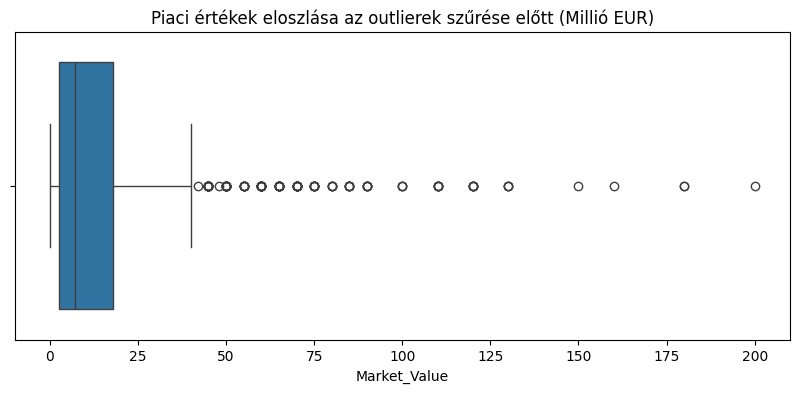

In [ ]:
print( "--- Outlierek szűrése seabornnal")
#Készítünk egy dobozdiagramot a piaci értékek eloszlásáról
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Market_Value'])
plt.title("Piaci értékek eloszlása az outlierek szűrése előtt (Millió EUR)")
plt.show()

In [ ]:
#Kiszűrjük a legextrémebb 1%-ot, hogy ne torzítsák a modellt
q99 = df['Market_Value'].quantile(0.99)
df = df[df["Market_Value"] <= q99]

print(f" Extrém kiugró értékek (>{q99:.1f}M EUR) eltávolítva.")
print(f"Játékosok száma a szűrés után: {df.shape[0]} fő. \n")

 Extrém kiugró értékek (>100.0M EUR) eltávolítva.
Játékosok száma a szűrés után: 1947 fő. 



In [ ]:
print(" --- 2. Dummy változók generálása")
#Nemzetiségek egyszerűsítése (Angol, Spanyol, Francia, Egyéb csoportok)
def categorize_nationality(country):
  if country == "England" : return "English"
  elif country == "Spain" : return "Spanish"
  elif country == "France" : return "French"
  else: return "Other"

df["Nationality_Group"] = df["country_of_citizenship"].apply(categorize_nationality)

 --- 2. Dummy változók generálása


In [ ]:
#Bajnokságok dummyzása (Referencia: GB1)
league_dummies = pd.get_dummies(df["domestic_competition_id"], prefix="League", dtype=int)
league_dummies = league_dummies_drop("League_GB1", axis=1)

NameError: name 'league_dummies_drop' is not defined

In [ ]:
#Bajnokságok dummyzása (Referencia: GB1)
league_dummies = pd.get_dummies(df["domestic_competition_id"], prefix="League", dtype=int)
league_dummies = league_dummies.drop("League_GB1", axis=1)

In [ ]:
#Posztok dummyzása (Referencia: Attacker)
position_dummies = pd.get_dummies(df['position'], prefix="Pos" , dytpe=int)
if "Pos_Attack" in position_dummies.columns:
  position_dummies = position_dummies.drop("Pos_Attack", axis=1)

TypeError: get_dummies() got an unexpected keyword argument 'dytpe'

In [ ]:
#Posztok dummyzása (Referencia: Attacker)
position_dummies = pd.get_dummies(df['position'], prefix="Pos" , dtype=int)
if "Pos_Attack" in position_dummies.columns:
  position_dummies = position_dummies.drop("Pos_Attack", axis=1)

In [ ]:
#Nemzetiségek dummyzása (Referencia: English)
nat_dummies = pd.get_dummies(df["Nationlity_Group"], prefix="Nat", dtype=int)
nat_dummies = nat_dummies.drop("Nat_English", axis=1)

KeyError: 'Nationlity_Group'

In [ ]:
#Nemzetiségek dummyzása (Referencia: English)
nat_dummies = pd.get_dummies(df["Nationality_Group"], prefix="Nat", dtype=int)
nat_dummies = nat_dummies.drop("Nat_English", axis=1)

In [ ]:
#táblázat összeállítása dummykkal
df_model = pd.concat([df[['Age', "Minutes_Played", "Contract_Years_Left", "Goal_Contributions", "Market_Value""]],
league_dummies, position_dummies, nat_dummies], axis=1)

SyntaxError: unterminated string literal (detected at line 2) (4228721836.py, line 2)

In [ ]:
df_model = pd.concat([df[['Age', 'Minutes_Played', 'Contract_Years_Left', 'Goal_Contributions', 'Market_Value']],
                      league_dummies, position_dummies, nat_dummies], axis=1)

In [ ]:
print(" Dummy változók legenerálva.")
display(df_model.head(3))

 Dummy változók legenerálva.


,Age,Minutes_Played,Contract_Years_Left,Goal_Contributions,Market_Value,League_ES1,League_FR1,League_IT1,League_L1,Pos_Defender,Pos_Midfield,Nat_French,Nat_Other,Nat_Spanish
0,40.0,946,0.0,2,0.75,0,0,0,0,0,1,0,0,0
1,34.0,1288,1.0,6,2.00,0,0,0,1,0,1,0,1,0
2,36.0,2610,0.0,0,1.40,1,0,0,0,1,0,0,1,0


In [ ]:
#eredményváltozó és magyarázó változók szétválasztása
y= df_model['Market_Value"']
x = df_model.drop('Market_Value", axis=1')

KeyError: 'Market_Value"'

In [ ]:
#eredményváltozó és magyarázó változók szétválasztása
y= df_model['Market_Value']
x = df_model.drop('Market_Value', axis=1)

In [ ]:
#tengelymetszet hozzáadása

In [ ]:
x = sm.add_constant(x)

In [ ]:
#a modell illesztése és eredmények kiszámolása
model = sm.OLS(y, x).fit()

In [ ]:
print("A modell lefutott. Az eredmények:")
display(model.summary())

A modell lefutott. Az eredmények:


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           Market_Value   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     99.56
Date:                Tue, 02 Jun 2026   Prob (F-statistic):          4.30e-204
Time:                        20:14:05   Log-Likelihood:                -7680.9
No. Observations:                1947   AIC:                         1.539e+04
Df Residuals:                    1933   BIC:                         1.547e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  15.3706      2.470      6.223      0.000      10.527      20.215
Age                    -0.4228      0.076     -5.557      0.000      -0.572      -0.274
Minutes_Played          0.0029      0.000      8.245      0.000       0.002       0.004
Contract_Years_Left     1.7841      0.225      7.925      0.000       1.343       2.226
Goal_Contributions      0.9883      0.069     14.259      0.000       0.852       1.124
League_ES1             -9.2978      1.065     -8.727      0.000     -11.387      -7.208
League_FR1            -10.8308      0.986    -10.986      0.000     -12.764      -8.897
League_IT1             -8.8729      0.898     -9.883      0.000     -10.634      -7.112
League_L1             -10.2045      0.953    -10.702      0.000     -12.075      -8.335
Pos_Defender            2.6639      0.859      3.102      0.002       0.980       4.348
Pos_Midfield            2.0462      0.801      2.554      0.011       0.475       3.617
Nat_French              3.6150      1.455      2.484      0.013       0.761       6.469
Nat_Other               1.7227      1.159      1.486      0.137      -0.551       3.996
Nat_Spanish            -0.6935      1.531     -0.453      0.651      -3.696       2.309
==============================================================================
Omnibus:                      693.504   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3109.358
Skew:                           1.657   Prob(JB):                         0.00
Kurtosis:                       8.229   Cond. No.                     1.94e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.94e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
#Mivel mindegyik változó szignifikáns, illetve a nemzetiség dummynál legalább 1 ismérv(Nat_French) szignifikáns, ezért nem kell kivennünk egy változót sem a modellünkből

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
from IPython.display import display

In [ ]:
print("--- A modell jóságának értékelés globális F-próbával---")
#Kinyerjük a Python modell objektumából a globális F-próba pontos p-értékét
f_pvalue = model.f_pvalue
print(f"A globális F-próba p-értéke: {f_pvalue}")
print("Értékelés: Mivel ez az érték gyakorlatilag 0 (vastagon kisebb, mint a 0.05-ös küszöb),")
print("a modellünk globálisan szignifikáns. Ez azt jelenti, hogy a magyarázó változóink")
print("együttesen valóban képesek magyarázni a piaci értéket, és szignifikánsan jobb")
print("eredményt adnak annál, mintha mindenkinek csak az átlagos piaci értékét tippelnénk meg.\n")

--- A modell jóságának értékelés globális F-próbával---
A globális F-próba p-értéke: 4.3026506844626784e-204
Értékelés: Mivel ez az érték gyakorlatilag 0 (vastagon kisebb, mint a 0.05-ös küszöb),
a modellünk globálisan szignifikáns. Ez azt jelenti, hogy a magyarázó változóink
együttesen valóban képesek magyarázni a piaci értéket, és szignifikánsan jobb
eredményt adnak annál, mintha mindenkinek csak az átlagos piaci értékét tippelnénk meg.



In [ ]:
print("--- A multikollinearitás vizsgálata (VIF mutatók) ---")
# Létrehozunk egy üres táblázatot, amiben eltároljuk a változók neveit
vif_data = pd.DataFrame()
vif_data["Változó"] = x.columns

--- A multikollinearitás vizsgálata (VIF mutatók) ---


NameError: name 'X' is not defined

In [ ]:
print("--- A multikollinearitás vizsgálata (VIF mutatók) ---")
# Létrehozunk egy üres táblázatot, amiben eltároljuk a változók neveit
vif_data = pd.DataFrame()
vif_data["Változó"] = x.columns

--- A multikollinearitás vizsgálata (VIF mutatók) ---


In [ ]:
# Egy ciklus segítségével kiszámoljuk a VIF értéket az x mátrix minden egyes oszlopára
vif_data["VIF_Érték"] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]

In [ ]:
print("VIF mutatók sikeresen kiszámolva!")
print(" Az 5 feletti érték")
print("veszélyes multikollinearitást (erős együttmozgást) jelez a magyarázó változók között.")

# Csökkenő sorrendben, 2 tizedesjegyre kerekítve kiíratjuk a táblázatot
display(vif_data.sort_values(by="VIF_Érték", ascending=False).round(2))

VIF mutatók sikeresen kiszámolva!
 Az 5 feletti érték
veszélyes multikollinearitást (erős együttmozgást) jelez a magyarázó változók között.


,Változó,VIF_Érték
0,const,75.42
12,Nat_Other,3.63
13,Nat_Spanish,3.40
11,Nat_French,2.52
5,League_ES1,2.26
9,Pos_Defender,2.18
4,Goal_Contributions,2.06
2,Minutes_Played,1.77
10,Pos_Midfield,1.71
6,League_FR1,1.70
